In [3]:
import pandas as pd
import numpy as np
import random
import math
from numpy import pi
from numpy import sqrt
import matplotlib.pyplot as plt

In [ ]:
import sys
from pathlib import Path
import importlib

cwd = Path.cwd().resolve()
for folder in [cwd] + list(cwd.parents):
    if (folder / "utils.py").is_file():
        sys.path.insert(0, str(folder))
        utils = importlib.import_module("utils")
        break
else:
    raise FileNotFoundError("utils.py not found in project root or any parent directory")

In [ ]:
from utils import init

dataset = init()


In [ ]:
#Grab Baltimore Total Data

store_kys = []
store_dts = []

for i in range( 7882, 10000):
    if "Baltimore" in dataset["CUA"].iloc[i]:
        store_kys.append(dataset["CUA"].iloc[i])
        store_dts.append(dataset["Total"].iloc[i])


In [ ]:
data_size = 16

trend_dict = { i:store_dts[i] for i in range(data_size)} 

In [9]:
print( trend_dict)

{0: 13, 1: 267, 2: 39, 3: 99, 4: 39, 5: 89, 6: 49, 7: 87, 8: 73, 9: 44, 10: 41, 11: 63, 12: 45, 13: 47, 14: 136, 15: 164}


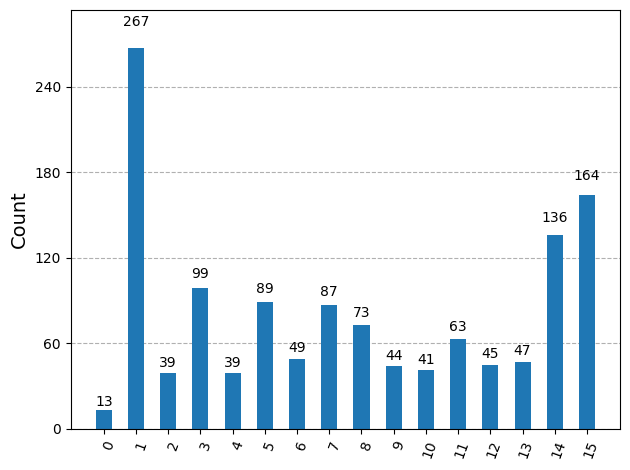

In [10]:
from qiskit.visualization import plot_histogram

plot_histogram( trend_dict)

USING APPROXIMATE AMPLITUDE AMPLIFICATION TO ENCODE DATA

In [11]:
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector

In [12]:
# Custom histogram plot to show difference between encoding and actual data

def bar_text( bars, ax, offset = 0.01, color = "black", set_height = False ):

    for bar in bars:
        height = bar.get_height()

        if set_height:
            ax.text(    bar.get_x() + bar.get_width() / 2,    offset,    f"{height:.2f}",    ha='center',    va='bottom',    fontsize=8 , color = color)
        else:
            ax.text(    bar.get_x() + bar.get_width() / 2,    height + offset,    f"{height:.2f}",    ha='center',    va='bottom',    fontsize=8 , color = color)

def custom_plot_dict_histogram( data_dict, bg_dict, label_ref, fig_size = (10,5), show_values = True, label_name_a =" AAE State", label_name_b =" Target State", label_string= True):

    fig, ax = plt.subplots( figsize= fig_size)

    all_labels = [ label for label in label_ref]
    
    if label_string is False:
        all_labels = [str(label) for label in label_ref]


    if bg_dict is not None:
        target_values = [ bg_dict.get( label, 0) for label in all_labels]

    data = data_dict
    dict_values = [ data.get(label, 0) for label in all_labels]

    #diff_values =
    if bg_dict is not None:
        max_v = max( max( dict_values), max( target_values ) ) + 0.05
    else:
        max_v = max( dict_values ) + 0.05

    if bg_dict is not None:    
        bars = ax.bar(all_labels, target_values, color = "red", alpha= 0.4, edgecolor='black', linewidth=1.2, label= label_name_b )
        if show_values:
            bar_text( bars, ax, max_v - 0.02, color= "red", set_height= True)

    
    barsb = ax.bar(all_labels, dict_values, color = "blue", alpha= 0.5, edgecolor='black', linewidth=1.2, label= label_name_a )
    if show_values:
        bar_text( barsb, ax, max_v - 0.03, color= "blue", set_height= True)


    # FIX: use correct scale
    ax.set_ylim(0, max_v)   # ← change from 100 to 1
    ax.set_xlabel("State")
    ax.set_ylabel("Probability")
    ax.legend(loc="best")#"upper right")
    plt.show()



Approximate Amplitude Encoding 

Ansatz: Hardware Efficient Ansatz (HEA)

In [ ]:
#region: load conditions


bit_size = int( math.log2( data_size) )
layers = 4 

rotation_layers = 1
param_size = (bit_size *layers)*rotation_layers


#endregion


# region: Hilbert Space Mapping( Map to hilbert space )
def create_possibility_space( n=3):
    bit_space = 2**n
    all_states = [ format(i, f'0{n}b') for i in range( bit_space)]

    #print( "possibility space: ", all_states)
    return all_states

bn_size = int(bit_size)#int( math.log2(bit_size) )
bit_space = bit_size

all_states = create_possibility_space( bn_size)

#endregion

#region: Ansatz Configuration Functions

# AAE Prepare Search State
def gen_CNOT_list( size, type = 0):

    if (type == 0):
        cnot_list = [ [i, i+1] for i in range(size - 1) ]
    
        return cnot_list
    else:

        cnot_list = [ [ i, i+1] for i in range( 0, size - 1, 2) ]
        cnot_listb = [ [ i+1, i+2] for i in range( 0, size-2, 2) ]
        
        cnot_list.extend( cnot_listb)
        return cnot_list

#ansatz_format = "XZX" #xzx - (z_entaglement)
ansatz_format = "YYY"

def Apply_circuit_rotation(  pos, ansatz_format, circuit, parameter, circ_index):
    gate = ansatz_format[pos]

    rotations = {
        "X": circuit.rx,
        "Y": circuit.ry,
        "Z": circuit.rz
    }

    try:
        rotations[gate](parameter, circ_index)
    except KeyError:
        raise ValueError(f"Unknown rotation type '{gate}' at position {pos}")

# entangIement_format = 

def init_ansatz( inputs, layers, parameters):

    circ = QuantumCircuit( inputs , inputs)

    circ.barrier()

    #for inp in range( inputs):
        #circ.h(inp)

    circ.barrier()
    cnot_list = gen_CNOT_list( inputs, 1)
    #print( cnot_list)

    param_index = 0

    for n in range( layers):
        #circ.barrier()

        # group a (ry)
        for i in range( inputs):
            for rot in range( rotation_layers):
                Apply_circuit_rotation( 0, ansatz_format, circ, parameters[ param_index], i)
                param_index += 1
            


        #group b (cnot)
        for a,b in cnot_list:
            circ.cx( a,b)
        circ.barrier()
        
        #region: group c ( entangler)
        #for a,b in cnot_list:
        #    circ.cry( parameters[param_index], a, b)
        #    param_index += 1
        #circ.cry( parameters[param_index], inputs-1, 0)
        #endregion

    #print( circ)
    return circ

def append_ansatz( circ, inputs, offset, layers, parameters):


    circ.barrier()

    #for inp in range( inputs):
    #    circ.h(inp+offset)

    circ.barrier()
    cnot_list = gen_CNOT_list( inputs, 1)

    param_index = 0

    for n in range( layers):
        #circ.barrier()

        # group a (ry)
        for i in range( inputs):
            for rot in range( rotation_layers):
                Apply_circuit_rotation( 0, ansatz_format, circ, parameters[ param_index], i + offset)
                param_index += 1

        #group b (cnot)
        for a,b in cnot_list:
            circ.cx( offset + a, offset + b)
        circ.barrier()
        
        #region: group c ( entangler)
        #for a,b in cnot_list:
        #    circ.cry( parameters[param_index], a, b)
        #    param_index += 1
        #circ.cry( parameters[param_index], inputs-1, 0)
        #endregion

    #print( circ)
    return circ

def append_inverse_ansatz( circ, inputs, offset, layers, parameters, reverse_rotations= True, entangle_chain= True):

    parameters = parameters.reshape( layers,inputs)[::-1].flatten()

    circ.barrier()

    #for inp in range( inputs):
    #    circ.h(inp)

    circ.barrier()
    cnot_list = gen_CNOT_list( inputs, 1)

    param_index = 0

    for n in range( layers):
        #group b (cnot)
        circ.barrier()

        if entangle_chain: 
            for a,b in cnot_list[::-1]:
                circ.cx( offset + a, offset + b)

        circ.barrier()
        # group a (ry)
        for i in range( inputs):
            for rot in range( rotation_layers):

                sn = 1 if reverse_rotations else -1 #reverse rotation angle

                Apply_circuit_rotation( 0, ansatz_format, circ, sn*parameters[ param_index], i + offset)

                param_index += 1

        
        circ.barrier()
        
        #region: group c ( entangler)
        #for a,b in cnot_list:
        #    circ.cry( parameters[param_index], a, b)
        #    param_index += 1
        #circ.cry( parameters[param_index], inputs-1, 0)
        #endregion

        #for inp in range( inputs):
        #    circ.h(inp+offset)

    #print( circ)
    return circ

def extract_qc_output(qc):
    backend = Aer.get_backend("qasm_simulator")

    compiled_circuit = transpile(qc, backend)

    job = backend.run(compiled_circuit, shots=1024)
    result = job.result()

    counts = result.get_counts()

    # Convert to probabilities
    total_shots = sum(counts.values())
    probs = {key: value / total_shots for key, value in counts.items()}
    
    return probs

def extract_statevector_output(qc, reverse_bits=False):

    backend = Aer.get_backend("statevector_simulator")

    qc_sv = qc.remove_final_measurements(inplace=False)

    compiled_circuit = transpile(qc_sv, backend)
    result = backend.run(compiled_circuit).result()

    statevector = result.get_statevector()

    probs_dict = Statevector(statevector).probabilities_dict()

    if reverse_bits:
        probs_dict = {k[::-1]: v for k, v in probs_dict.items()}


    return probs_dict

def Measure_Probabilities( circ, method="qasm", reverse_bits=False ):

    if method=="qasm":
        # Choose backend
        backend = Aer.get_backend("qasm_simulator")

        compiled_circuit = transpile( circ, backend)


        job = backend.run(compiled_circuit, shots=1024)
        result = job.result()

        counts = result.get_counts()

        total_shots = sum(counts.values())
        prob_dict = { key: value/total_shots for key, value in counts.items() }

    else:
        backend = Aer.get_backend("statevector_simulator")

        qc_sv = circ.remove_final_measurements(inplace=False)

        compiled_circuit = transpile(qc_sv, backend)
        result = backend.run(compiled_circuit).result()

        statevector = result.get_statevector()

        prob_dict = Statevector(statevector).probabilities_dict()

    if reverse_bits:
        prob_dict = { k: v for k, v in prob_dict.items()}

    max_value_key = max( prob_dict, key= prob_dict.get)

    return max_value_key, prob_dict


#endregion

#region: AAE Training Optimizer Functions

def forward( parameters, _layers, input, base_circuit = None):
    # Bind parameters
    #bound_qc = circuit.bind_parameters({p: v for p, v in zip(circuit.parameters, weight_params)})
    
    if base_circuit is None:
        bound_qc = init_ansatz( input, _layers, parameters)
    else:
        bound_qc = append_ansatz( base_circuit, input, 0, _layers, parameters,reverse_rotations= False, entangle_chain= False )

    bound_qc.measure(range( input), range( input))
    #state_dict = extract_qc_output( bound_qc)
    state_dict = extract_statevector_output( bound_qc)
    return state_dict

# loss functions
def cross_entropy(prediction, target, possibility_space, eps=1e-12):
    return -sum(    target.get(s, 0) * math.log(prediction.get(s, eps) + eps)    for s in possibility_space )

def mse_loss( prediction, target, possibility_space):
    #mse = sum( ( prediction.get(s, 0) - target.get(s, 0))**2 for s in possibility_space) / len( possibility_space)
    mse = sum((prediction.get(s, 0) - target.get(s, 0))**2 for s in possibility_space)
    return mse

def AAE_Model(epoch=2, iterations=200, _method="COBYLA", input_size= 3, layers= 2, parameter_size = 4, encode_state= None, show_progress = True, _Base_circuit = None):


    epoch_records = []
    loss_records = []
    progress_records = []
    transform_records = []

    global_best_loss = float('inf')
    global_best_params = None
    patience = 50
    #no_improve_steps = 0
    #last_best = float('inf')

    params = np.random.uniform( -np.pi, np.pi, size=parameter_size)
    #params = np.array( [np.pi/2]*param_size)#np.random.uniform(-np.pi, np.pi, size=param_size)

    for i in range(epoch):

        if show_progress:
            print("epoch:", i)

        step = 0
        epoch_best_loss = float('inf')
        epoch_best_params = None

        last_best = float('inf')
        no_improve_steps = 0

        def loss_fn(p, repeats= 1):
            #return mse_loss( forward(p, input=input_size, base_circuit= _Base_circuit, _layers= layers), encode_state, all_states)
            return 1000*sum( mse_loss( forward(p, input=input_size, _layers= layers), encode_state, all_states ) for _ in range(repeats) ) / repeats
            #return sum( cross_entropy( forward(p, input=input_size, _layers= layers), encode_state, all_states ) for _ in range(repeats) ) / repeats
        
        def callback(xk):
            nonlocal no_improve_steps, last_best
            nonlocal step, epoch_best_loss, epoch_best_params
            nonlocal global_best_loss, global_best_params
            best_check = ""

            step += 1

            loss = loss_fn(xk)

            # early stopping patience tracking
            if loss < last_best - 1e-6:
                last_best = loss
                no_improve_steps = 0
            else:
                no_improve_steps += 1

            # epoch best
            if loss < epoch_best_loss:
                epoch_best_loss = loss
                epoch_best_params = xk.copy()

            # global best + RECORD
            if loss < global_best_loss:
                global_best_loss = loss
                global_best_params = xk.copy()
                
                progress_records.append( [ i, loss])

                if show_progress:
                    #print("New Global Best:", global_best_loss)
                    best_check = ": New Global Best."

            loss_records.append(loss)
            transform_records.append(xk.copy())
            epoch_records.append( i)

            if show_progress:
                print("step:", step, "loss:", loss, best_check)


            if ( show_progress and step % 50 == 0):
                print("step:", step, "loss:", loss, "epoch best:", epoch_best_loss)

        res = minimize( loss_fn, params, method=_method, callback=callback, options={"maxiter": iterations} )

        # choose next starting point
        if epoch_best_params is not None:
            params = epoch_best_params
        else:
            params = res.x


        if show_progress:
            print("done: Best loss:", global_best_loss)
            

        # eary stopping
        if global_best_loss <= 0.0:  
            break
        
        if no_improve_steps >= patience:
            break
    return transform_records, loss_records, epoch_records, progress_records

#endregion



In [14]:

# prepare data for quantum circuit
def data_to_quantum_state( data, hilbert_map):

    normalized_data = np.array( data.copy(), dtype=np.float64)

    norm_sum = np.sum( normalized_data) #np.sum( normalized_data**2 )
    if norm_sum == 0:
        return None, 0
    else:
        normalized_data /= norm_sum#sqrt( norm_sum )


    data_size = len( data)
    quantum_state = { hilbert_map[i]: normalized_data[i] for i in range( data_size) }

    return quantum_state, norm_sum


def quantum_state_to_data( state, normalize_factor,  size_xy):
    res_grid = [0]*( size_xy)

    init_qbit_size = int( math.log2( size_xy) )
    label_ref = create_possibility_space( init_qbit_size)

    st_count = len( label_ref)

    for i in range( st_count):
        if label_ref[i] in state:
            res_grid[i] =  state[ label_ref[i] ]


    #res_grid = [ (i* normalize_factor)**0.5 for i in res_grid ]
    res_grid = [ (i* normalize_factor) for i in res_grid ]
    res_grid = np.array( res_grid)

    return res_grid



In [15]:
print( trend_dict)

{0: 13, 1: 267, 2: 39, 3: 99, 4: 39, 5: 89, 6: 49, 7: 87, 8: 73, 9: 44, 10: 41, 11: 63, 12: 45, 13: 47, 14: 136, 15: 164}


In [16]:
target_state, nsum = data_to_quantum_state( list( trend_dict.values() ), all_states )
print( target_state, nsum)

{'0000': 0.010038610038610039, '0001': 0.20617760617760617, '0010': 0.030115830115830116, '0011': 0.07644787644787644, '0100': 0.030115830115830116, '0101': 0.06872586872586872, '0110': 0.03783783783783784, '0111': 0.06718146718146718, '1000': 0.05637065637065637, '1001': 0.03397683397683398, '1010': 0.03166023166023166, '1011': 0.04864864864864865, '1100': 0.03474903474903475, '1101': 0.036293436293436294, '1110': 0.10501930501930502, '1111': 0.12664092664092663} 1295.0


In [17]:
epoch_set = 2

transform_records, loss_records, epoch_records, progress_records = AAE_Model( epoch= epoch_set, input_size= bit_size, layers= layers, parameter_size= param_size, encode_state= target_state, show_progress= True)


epoch: 0
step: 1 loss: 35.11409030408745 : New Global Best.
step: 2 loss: 33.092953751737376 : New Global Best.
step: 3 loss: 33.092953751737376 
step: 4 loss: 31.508997359955057 : New Global Best.
step: 5 loss: 31.508997359955057 
step: 6 loss: 31.508997359955057 
step: 7 loss: 31.412766076142738 : New Global Best.
step: 8 loss: 28.24034077142813 : New Global Best.
step: 9 loss: 20.341536674877595 : New Global Best.
step: 10 loss: 16.419004874496547 : New Global Best.
step: 11 loss: 12.38020737882086 : New Global Best.
step: 12 loss: 11.46421932042622 : New Global Best.
step: 13 loss: 11.20931635139385 : New Global Best.
step: 14 loss: 11.20931635139385 
step: 15 loss: 11.20931635139385 
step: 16 loss: 11.20931635139385 
step: 17 loss: 11.20931635139385 
step: 18 loss: 11.049797599288368 : New Global Best.
step: 19 loss: 10.713092125058655 : New Global Best.
step: 20 loss: 10.20103557555332 : New Global Best.
step: 21 loss: 10.08328151840796 : New Global Best.
step: 22 loss: 10.048031

In [18]:

state = init_ansatz( bit_size, layers, transform_records[-1] )
state.measure( range( bit_size), range( bit_size) )
state.draw()


░  ░ ┌──────────────┐           ░ ┌─────────────┐            ░ »
q_0: ─░──░─┤ Ry(0.034911) ├──■────────░─┤ Ry(-1.0288) ├───■────────░─»
      ░  ░ └┬────────────┬┘┌─┴─┐      ░ ├─────────────┤ ┌─┴─┐      ░ »
q_1: ─░──░──┤ Ry(3.9657) ├─┤ X ├──■───░─┤ Ry(-1.3852) ├─┤ X ├──■───░─»
      ░  ░ ┌┴────────────┤ └───┘┌─┴─┐ ░ └┬────────────┤ └───┘┌─┴─┐ ░ »
q_2: ─░──░─┤ Ry(-1.1454) ├───■──┤ X ├─░──┤ Ry(4.5028) ├───■──┤ X ├─░─»
      ░  ░ ├─────────────┤ ┌─┴─┐└───┘ ░ ┌┴────────────┴┐┌─┴─┐└───┘ ░ »
q_3: ─░──░─┤ Ry(0.19286) ├─┤ X ├──────░─┤ Ry(-0.56527) ├┤ X ├──────░─»
      ░  ░ └─────────────┘ └───┘      ░ └──────────────┘└───┘      ░ »
c: 4/════════════════════════════════════════════════════════════════»
                                                                     »
«      ┌────────────┐           ░ ┌─────────────┐           ░ ┌─┐         
«q_0: ─┤ Ry(2.9895) ├──■────────░─┤ Ry(0.27394) ├──■────────░─┤M├─────────
«     ┌┴────────────┤┌─┴─┐      ░ └┬────────────┤┌─┴─┐      ░ └╥┘┌─┐      
«q_1: ┤ Ry(0.45059) ├┤ X ├──■───░──┤ Ry(2.1621) ├┤ X ├──■───░──╫─┤M├──────
«     ├─────────────┤└───┘┌─┴─┐ ░  ├────────────┤└───┘┌─┴─┐ ░  ║ └╥┘┌─┐   
«q_2: ┤ Ry(-2.7187) ├──■──┤ X ├─░──┤ Ry(2.5666) ├──■──┤ X ├─░──╫──╫─┤M├───
«     └┬────────────┤┌─┴─┐└───┘ ░ ┌┴────────────┤┌─┴─┐└───┘ ░  ║  ║ └╥┘┌─┐
«q_3: ─┤ Ry(2.0848) ├┤ X ├──────░─┤ Ry(0.23568) ├┤ X ├──────░──╫──╫──╫─┤M├
«      └────────────┘└───┘      ░ └─────────────┘└───┘      ░  ║  ║  ║ └╥┘
«c: 4/═════════════════════════════════════════════════════════╩══╩══╩══╩═
«                                                              0  1  2  3

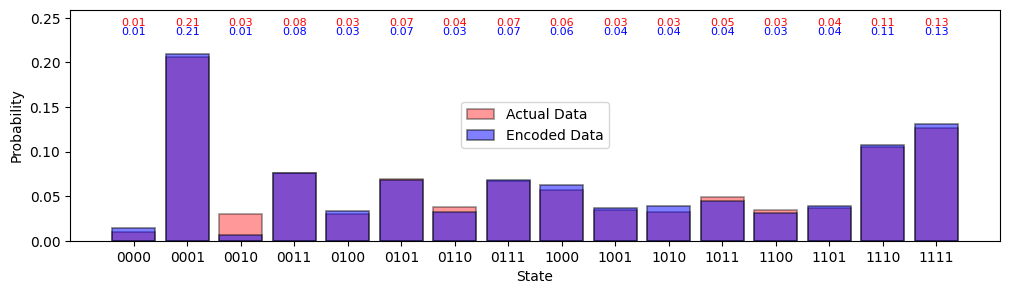

In [25]:
#res_b, res_prob = Measure_Probabilities(  state, method="statevector", reverse_bits=True )
res_prob = extract_statevector_output( state)#forward( transform_records[-1], 4, bit_size, None)
recon_data = quantum_state_to_data( res_prob, nsum, data_size)
recon_dict = {i:recon_data[i] for i in range(len(recon_data) ) }
custom_plot_dict_histogram( res_prob, target_state, all_states, fig_size=(12,3), label_name_a="Encoded Data", label_name_b="Actual Data")
id_ref = list( range( data_size) )

#custom_plot_dict_histogram( recon_dict, trend_dict, id_ref)

In [23]:
print( trend_dict)
print( recon_dict)

{0: 13, 1: 267, 2: 39, 3: 99, 4: 39, 5: 89, 6: 49, 7: 87, 8: 73, 9: 44, 10: 41, 11: 63, 12: 45, 13: 47, 14: 136, 15: 164}
{0: 17.947056028715547, 1: 270.7555436265443, 2: 7.70209234363849, 3: 98.70988346829182, 4: 43.32060216522341, 5: 88.50079861911614, 6: 42.02863667599541, 7: 88.84865185973663, 8: 81.15439291773619, 9: 48.051899415640044, 10: 51.037699296228034, 11: 58.269622937268714, 12: 40.795445877622996, 13: 50.41237982472256, 14: 138.6123146587443, 15: 168.8529802847755}
